In [484]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Were created in create_adj_embs.
adj_embs = torch.load('data/graphs/weighted/adj_embs.pt')

In [3]:
similarities_np = cosine_similarity(adj_embs.detach().numpy())
assert np.allclose(similarities_np, similarities_np.T, atol=1e-6)

In [4]:
# similarities = torch.tensor(similarities_np)
# assert torch.allclose(similarities, similarities.T, atol=1e-6)

similarities = similarities_np

In [5]:
import pickle

with open('data/graphs/weighted/adj_feats__cosine__similarities.pickle', 'wb') as f:
    pickle.dump(similarities, f)

(array([1.3944e+04, 9.1000e+01, 8.6000e+01, 6.5000e+01, 2.6000e+01,
        2.9000e+01, 4.9000e+01, 2.3000e+01, 1.0000e+01, 2.0000e+01]),
 array([0.        , 0.08044324, 0.16088649, 0.24132973, 0.32177298,
        0.40221622, 0.48265947, 0.56310271, 0.64354596, 0.7239892 ,
        0.80443244]),
 <BarContainer object of 10 artists>)

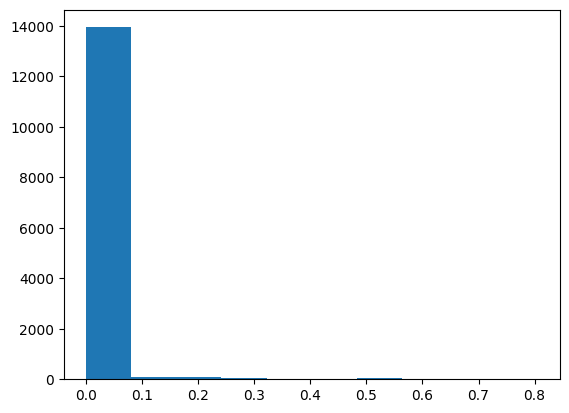

In [6]:
import matplotlib.pyplot as plt

plt.hist(similarities[0][1:])

In [7]:
similarities[0][1:].min(), similarities[0][1:].max()

(0.0, 0.8044324442267727)

In [8]:
for i in range(len(similarities)):
    similarities[i][i] = float('nan')

Отличие двух имплементаций ниже в возвращаемом типе. В первом случае возвращается список отсортированных списков, во втором - список множеств. Сложность первого - O(n*log(n)), второго - O(n).

In [9]:
from typing import List, Iterable, Optional


def create_sorted_bins_for_user(values: Iterable[int], 
                                n_bins: int, 
                                exclude_id: Optional[int] = None) -> List[List[int]]:
    indexed_values = list((idx, val) for idx, val in enumerate(values) if idx != exclude_id)
    indexed_values.sort(key=lambda x: x[1])

    min_val, max_val = indexed_values[0][1], indexed_values[-1][1]
    bin_size = (max_val - min_val) / n_bins
    
    bins = [[] for _ in range(n_bins)]
    
    # eps был добавлен, чтобы не делить на 0, если все элементы имеют одно значение.
    # в цикле есть обработка ситуации, когда bin_idx = n_bins (заметим, что при данной имплементации
    # правая граница бина в него не входит и поэтому отдельная обработка). 
    # Эта обработка также становится ненужной с eps
    eps = 1e-6
    for idx, val in indexed_values:
        bin_idx = int((val - min_val) // (bin_size + eps))
        if bin_idx == n_bins:
            bin_idx -= 1
        bins[bin_idx].append(idx)

    return bins

In [10]:
from typing import List, Iterable, Optional, Set

def create_bins_for_user(values: Iterable[int], 
                         n_bins: int, 
                         exclude_id: Optional[int] = None) -> List[Set[int]]:
    indexed_values = list((idx, val) for idx, val in enumerate(values) if idx != exclude_id)

    # `indexed_values` is used instead of `values` to exclude `exclude_id` from the calculation
    min_val, max_val = min(indexed_values, key=lambda x: x[1])[1], max(indexed_values, key=lambda x: x[1])[1]
    bin_size = (max_val - min_val) / n_bins
    
    bins = [set() for _ in range(n_bins)]
    
    # eps был добавлен, чтобы не делить на 0, если все элементы имеют одно значение.
    # в цикле есть обработка ситуации, когда bin_idx = n_bins (заметим, что при данной имплементации
    # правая граница бина в него не входит и поэтому отдельная обработка). 
    # Эта обработка также становится ненужной с eps
    eps = 1e-6
    for idx, val in indexed_values:
        bin_idx = int((val - min_val) // (bin_size + eps))
        if bin_idx == n_bins:
            bin_idx -= 1
        bins[bin_idx].add(idx)

    bins = tuple(tuple(bin_) for bin_ in bins)
        
    return bins

In [11]:
def test_create_bins_for_user(create_bins_for_user_fn, bins_are_sets=False):
    # Test 1: Basic test with 3 bins
    values = [5, 3, 8, 6, 2, 7, 1, 9]
    n_bins = 3
    bins = create_bins_for_user_fn(values, n_bins)
    expected = [[6, 4, 1], [0, 3], [5, 2, 7]]
    if bins_are_sets:
        expected = [set(bin) for bin in expected]
    assert bins == expected, f"Expected {expected}, but got {bins}"

    # Test 2: Test with 2 bins
    values = [10, 20, 30, 40, 50]
    n_bins = 2
    bins = create_bins_for_user_fn(values, n_bins)
    expected = [[0, 1, 2], [3, 4]]
    if bins_are_sets:
        expected = [set(bin) for bin in expected]
    assert bins == expected, f"Expected {expected}, but got {bins}"

    # Test 3: Test with 1 bin (all values should be in the same bin)
    values = [10, 20, 30, 40, 50]
    n_bins = 1
    bins = create_bins_for_user_fn(values, n_bins)
    expected = [[0, 1, 2, 3, 4]]
    if bins_are_sets:
        expected = [set(bin) for bin in expected]
    assert bins == expected, f"Expected {expected}, but got {bins}"

    # Test 4: Test with all values being the same
    values = [100, 100, 100, 100, 100]
    n_bins = 1
    bins = create_bins_for_user_fn(values, n_bins)
    expected = [[0, 1, 2, 3, 4]]
    if bins_are_sets:
        expected = [set(bin) for bin in expected]
    assert bins == expected, f"Expected {expected}, but got {bins}"

    # Test 5: Test with excluding a value
    values = [10, 20, 30, 40, 50]
    n_bins = 2
    exclude_id = 2
    bins = create_bins_for_user_fn(values, n_bins, exclude_id)
    expected = [[0, 1], [3, 4]]
    if bins_are_sets:
        expected = [set(bin) for bin in expected]
    assert bins == expected, f"Expected {expected}, but got {bins}"

    # Test 6: Test with expected empty bins
    values = [1, 2, 2, 2, 100, 101, 101]
    n_bins = 5
    bins = create_bins_for_user_fn(values, n_bins)
    if bins_are_sets:
        expected = [set(bin) for bin in expected]
    print(bins)


    # # Test 6: Test with more bins than values (some bins will be empty)
    # values = [1, 2, 3]
    # n_bins = 5
    # bins = create_bins_for_user_fn(values, n_bins)
    # expected = [[0], [1], [2], [], []]
    # assert bins == expected, f"Expected {expected}, but got {bins}"

    # # Test 7: Test with empty values
    # values = []
    # n_bins = 3
    # bins = create_bins_for_user_fn(values, n_bins)
    # expected = [[], [], []]
    # assert bins == expected, f"Expected {expected}, but got {bins}"

    # # Test 8: Test with a single value
    # values = [42]
    # n_bins = 3
    # bins = create_bins_for_user_fn(values, n_bins)
    # expected = [[0], [], []]
    # assert bins == expected, f"Expected {expected}, but got {bins}"

    print("All tests passed!")

# Run the tests
test_create_bins_for_user(create_sorted_bins_for_user)
test_create_bins_for_user(create_bins_for_user, bins_are_sets=True)

[[0, 1, 2, 3], [], [], [], [4, 5, 6]]
All tests passed!


AssertionError: Expected [{1, 4, 6}, {0, 3}, {2, 5, 7}], but got ((1, 4, 6), (0, 3), (2, 5, 7))

In [12]:
from tqdm import tqdm

n_bins = 10
n_users = len(similarities)

user_bins = []

for anchor_user_id, anchor_user_similarities in tqdm(enumerate(similarities), total=len(similarities)):
    user_bins.append(create_bins_for_user(anchor_user_similarities, n_bins, exclude_id=anchor_user_id))

user_bins = tuple(user_bins)

100%|██████████| 14344/14344 [02:46<00:00, 86.08it/s]


In [18]:
len(user_bins)

14344

In [ ]:
import json

json.dump(user_bins, )

In [14]:
import sys

def sizeof(obj):
    size = sys.getsizeof(obj)
    if isinstance(obj, dict): return size + sum(map(sizeof, obj.keys())) + sum(map(sizeof, obj.values()))
    if isinstance(obj, (list, tuple, set, frozenset)): return size + sum(map(sizeof, obj))
    return size

In [15]:
sizeof(user_bins) 

7414012012

In [16]:
7414012012 / 1024 / 1024 / 1024

6.904836755245924

In [15]:
14882685100 / 1024 / 1024 / 1024

13.86058060452342

In [21]:
type(user_bins[0][0])

frozenset

In [17]:
type(user_bins), type(user_bins[0]), type(user_bins[0][0])

(tuple, tuple, frozenset)

**Tuple[Tuple[FrozenSet[int]]]**

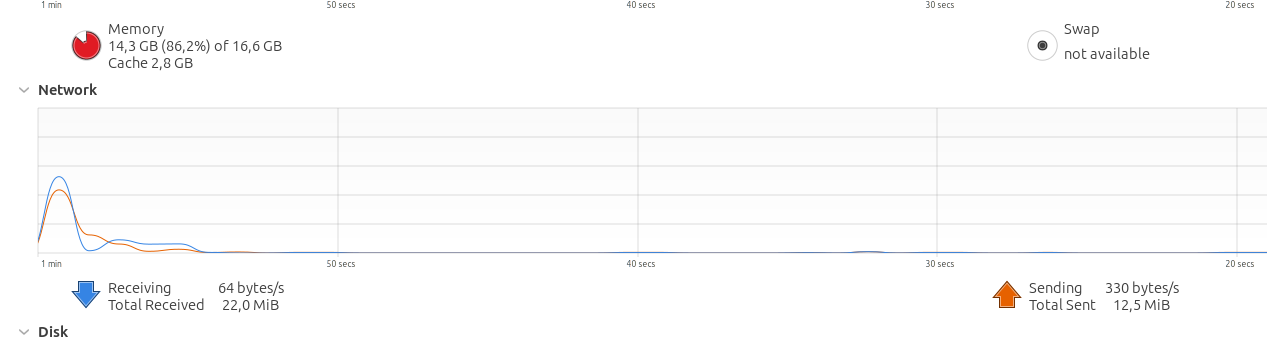

`sizeof(user_bins)` = 6236902028 ~ 6.2Gb

**List[np.array[frozenset]]

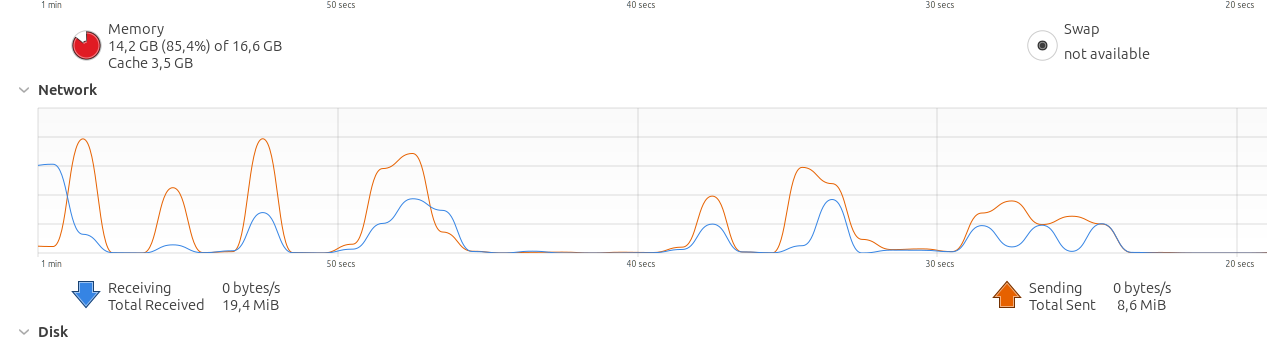

In [15]:
user_bins[0][0].nbytes

AttributeError: 'frozenset' object has no attribute 'nbytes'

In [ ]:
sizeof(user_bins)

**If there was no overhead**

6002 rows x 14353 ints per row x 4 bytes per bit = 344256000 bytes ~ 340Mb

**List[List[Set[int]]]:**


6002 rows


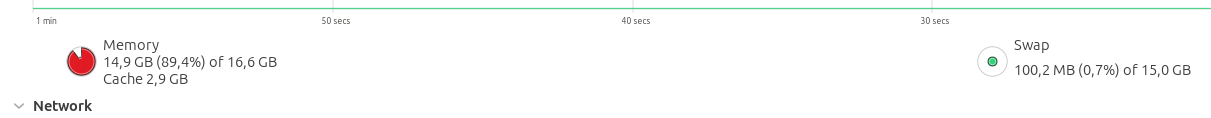


`sizeof(user_bins)` = 6530665628 ~ 6.5Gb

In [23]:
for anchor_user_id, anchor_user_bins in enumerate(user_bins):
    new_anchor_user_bins = [frozenset(bin_) for bin_ in anchor_user_bins]
    user_bins[anchor_user_id] = new_anchor_user_bins


In [24]:
sizeof(user_bins)

6237286556

**After conversion to frozenset**

**List[List[FrozenSet[int]]]:**

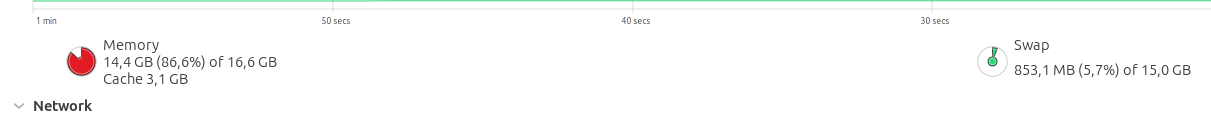

`sizeof(user_bins)` = 6237286556 ~ 6.2Gb

In [25]:
bins_array = np.array(user_bins, dtype=object)

In [26]:
sizeof(bins_array)

480288

In [ ]:
sizeof(bins_array)

480288

In [1]:
import pickle

with open('data/graphs/weighted/bins__adj_embs-cosine_similarity-no_postprocessing.pickle', 'rb') as f:
    user_bins = pickle.load(f)

for anchor_user_id, anchor_user_bins in enumerate(user_bins):
    new_anchor_user_bins = [frozenset(bin_) for bin_ in anchor_user_bins]
    user_bins[anchor_user_id] = new_anchor_user_bins

In [490]:
import os
import pickle

BIN_OUTPUT_DIR_PATH = 'data/graphs/weighted/'
f_name = 'bins__adj_embs-tuple_tuple_tuple-cosine_similarity-no_postprocessing.pickle'

with open(os.path.join(BIN_OUTPUT_DIR_PATH, f_name), 'wb') as f:
    pickle.dump(user_bins, f)

In [491]:
n_empty_bins = 0
for anchor_user_bins in user_bins:
    for bin in anchor_user_bins:
        if not bin:
            n_empty_bins += 1
            

In [492]:
n_empty_bins / len(user_bins) / len(user_bins[0])

0.014974902398215282

In [493]:
import numpy as np

def compute_bin_n_elements_statistics(bins_list):
    # Determine the number of bin positions (based on the first sublist)
    num_bins = len(bins_list[0])
    
    statistics = []
    for i in tqdm(range(num_bins)):
        bin_group = [bins[i] for bins in bins_list if i < len(bins)]
        n_elements_in_each_i_group = [len(bin) for bin in bin_group]
        n_elements_in_each_i_group = np.array(n_elements_in_each_i_group)

        mean = np.mean(n_elements_in_each_i_group)
        std_dev = np.std(n_elements_in_each_i_group)
        min_val = np.min(n_elements_in_each_i_group)
        max_val = np.max(n_elements_in_each_i_group)
        
        statistics.append({
            'bin_index': i,
            'n_elements-mean': mean,
            'n_elements-std_dev': std_dev,
            'n_elements-min': min_val,
            'n_elements-max': max_val
        })
    
    return statistics


def compute_bin_statistics(bins_list):
    num_bins = len(bins_list[0])

    statistics = []
    for i in range(num_bins):
        bin_group = [bins[i] for bins in bins_list if i < len(bins)]
        flattened_bin_group = [item for sublist in bin_group for item in sublist]
        flattened_bin_group = np.array(flattened_bin_group)
        
        mean = np.mean(flattened_bin_group)
        std_dev = np.std(flattened_bin_group)
        min_val = np.min(flattened_bin_group)
        max_val = np.max(flattened_bin_group)
        
        statistics.append({
            'bin_index': i,
            'mean': mean,
            'std_dev': std_dev,
            'min': min_val,
            'max': max_val
        })
    
    return statistics



In [494]:
compute_bin_n_elements_statistics(user_bins)

100%|██████████| 10/10 [00:00<00:00, 113.01it/s]


[{'bin_index': 0,
  'n_elements-mean': 11566.745050195204,
  'n_elements-std_dev': 2126.7621353432205,
  'n_elements-min': 4751,
  'n_elements-max': 14343},
 {'bin_index': 1,
  'n_elements-mean': 1445.6347601784719,
  'n_elements-std_dev': 1065.5902031937694,
  'n_elements-min': 0,
  'n_elements-max': 4838},
 {'bin_index': 2,
  'n_elements-mean': 555.2979643056331,
  'n_elements-std_dev': 518.4681263367003,
  'n_elements-min': 0,
  'n_elements-max': 2987},
 {'bin_index': 3,
  'n_elements-mean': 279.67645008365866,
  'n_elements-std_dev': 295.99708293169726,
  'n_elements-min': 0,
  'n_elements-max': 2139},
 {'bin_index': 4,
  'n_elements-mean': 161.40679029559396,
  'n_elements-std_dev': 187.23299549632125,
  'n_elements-min': 0,
  'n_elements-max': 1609},
 {'bin_index': 5,
  'n_elements-mean': 104.80305354155047,
  'n_elements-std_dev': 133.03754324683007,
  'n_elements-min': 0,
  'n_elements-max': 1091},
 {'bin_index': 6,
  'n_elements-mean': 73.38078639152259,
  'n_elements-std_dev'

In [495]:
def remove_empty_bins_(bins_list: List[List[List[int]]]) -> None:
    for anchor_user_id, anchor_user_bins in enumerate(bins_list):
        new_anchor_user_bins = []
        for bin in anchor_user_bins:
            if bin:
                new_anchor_user_bins.append(bin)
        bins_list[anchor_user_id] = tuple[new_anchor_user_bins]



In [496]:
remove_empty_bins_(user_bins)

TypeError: 'tuple' object does not support item assignment

In [50]:
avg_n_bins = np.mean([len(bins) for bins in user_bins])
avg_n_bins

9.850250976017847

In [51]:
with open(os.path.join(BIN_OUTPUT_DIR_PATH, 'bins__adj_embs-cosine_similarity-deleted_empty_bins.pickle'), 'wb') as f:
    pickle.dump(user_bins, f)

In [57]:
# Check that for each user all users except the user themselves are in the bins
n_users = len(user_bins)

for anchor_user_id, anchor_user_bins in tqdm(enumerate(user_bins), total=n_users):
    bins_set = set()
    for bin in anchor_user_bins:
        bins_set.update(bin)
    assert bins_set == set(range(n_users)) - {anchor_user_id}

  0%|          | 0/14344 [00:00<?, ?it/s]

 61%|██████    | 8736/14344 [00:10<00:06, 845.47it/s]

In [14]:
similarities[0,1]

tensor(0.0060, dtype=torch.float64)

# Extra: 

In [ ]:
import dgl


GRAPH_FILE_PATH = 'data/graphs/weighted/train_graph.bin'

(g_list,), _ = dgl.load_graphs(GRAPH_FILE_PATH, [0])

g_list.edata['weight']

# Test bpr related classes

In [ ]:
import sys; import os; sys.path.append(os.path.abspath('..'))

In [458]:
from typing import List, Tuple, Set, Dict, Iterable

import numpy as np
import torch

from ptls_extension_2024_research.sampling_strategies.triplet_selector import TripletSelector


UserBinAbstract = Iterable[Iterable[int]]
UserBinsNoOrder = Iterable[Set[int]]
UserBinsList = Iterable[List[int]]
UserBinsSorted = Iterable[Iterable[int]]


def get_max_distance_idx__list(sorted_arr, margin):
    max_diff = float('-inf')
    max_diff_index = -1

    for i in range(margin, len(sorted_arr) - margin):
        diff = sorted_arr[i] - sorted_arr[i - 1]

        if diff > max_diff:
            max_diff = diff
            max_diff_index = i

    return max_diff_index


def get_max_distance_idx__tensor(sorted_arr, margin):
    diffs = sorted_arr[1:] - sorted_arr[:-1]
    return torch.argmax(diffs[margin:-margin]) + margin 


def sparate_bin_on_max_distance(user_ids_bin, similarities, 
                                min_elements_in_bin: int):
    sorted_similarities, indices = zip(*sorted((sim, idx) for idx, sim in enumerate(similarities)))

    max_diff_idx = get_max_distance_idx__list(sorted_similarities, min_elements_in_bin)

    bin_1_idxs, bin_2_idxs = indices[:max_diff_idx], indices[max_diff_idx:]

    user_ids_bin_1 = [user_ids_bin[idx] for idx in bin_1_idxs]
    user_ids_bin_2 = [user_ids_bin[idx] for idx in bin_2_idxs]

    assert len(user_ids_bin_1) >= min_elements_in_bin
    assert len(user_ids_bin_2) >= min_elements_in_bin

    return user_ids_bin_1, user_ids_bin_2



class BinSeparationStrategy:
    def __init__(self) -> None:
        raise NotImplementedError

class MaxDistanceBinSeparationStrategy(BinSeparationStrategy):
    def __init__(self, min_elements_in_bin: int) -> None:
        self.min_elements_in_bin = min_elements_in_bin

    def __call__(self, user_ids_bin: torch.Tensor, similarities: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        return sparate_bin_on_max_distance(user_ids_bin, similarities, self.min_elements_in_bin)



class UserBinsContainer:
    def __init__(self, 
                 bins_dict: List[UserBinsNoOrder],
                 local_user_id_to_global_user_id: Dict[int, int],
                 similarity_matrix: np.ndarray,
                 raise_on_bin_is_not_a_set: bool = False) -> None:
        self.bins_dict = bins_dict
        self.local_user_id_to_global_user_id = local_user_id_to_global_user_id
        self.global_user_id_to_local_user_id = {v: k for k,v in self.local_user_id_to_global_user_id.items()}
        self.similarity_matrix = similarity_matrix
        self.raise_on_bin_is_not_a_set = raise_on_bin_is_not_a_set

    def get_user_bins(self, user_id: int) -> UserBinsNoOrder:
        # IS NOT USED
        local_user_id = self.global_user_id_to_local_user_id[user_id]
        # Conversion to list, because tuple or set lead to indexation errors.
        return [[self.local_user_id_to_global_user_id[el] for el in bin] for bin in self.bins_dict[local_user_id]]

    def get_similarities(self, anchor_user_id: int, bin_with_ids: List[int]) -> np.ndarray:
        anchor_user_global_id = anchor_user_id
        bin_with_global_ids = bin_with_ids
        achor_user_local_id = self.global_user_id_to_local_user_id[anchor_user_global_id]
        bin_local_ids = [self.global_user_id_to_local_user_id[global_id] for global_id in bin_with_global_ids]
        return self.similarity_matrix[achor_user_local_id, bin_local_ids] 
    
    def get_batch_clusters_dict(self, ids: torch.Tensor) -> Dict[int, UserBinsList]:
        global_ids = ids
        local_ids_set = {self.global_user_id_to_local_user_id[global_id] for global_id in global_ids}
        batch_clusters_dict = {}
        for idx in local_ids_set:
            global_idx = self.local_user_id_to_global_user_id[idx]
            batch_clusters_dict[global_idx] = []
            for cluster in self.bins_dict[idx]:
                if not isinstance(cluster, set):
                    if self.raise_on_bin_is_not_a_set:
                        raise ValueError(f"Expected bins to be of type set, got {type(cluster)}")
                    cluster = set(cluster)

                intersection = cluster & local_ids_set
                if len(intersection) == 0:
                    continue
                batch_clusters_dict[global_idx].append(
                    [self.local_user_id_to_global_user_id[local_user_id] 
                     for local_user_id in intersection])
        return batch_clusters_dict



def get_two_differenct_random_numbers(max_val):
    a = torch.randint(0, max_val, (1,)).item()
    b = torch.randint(0, max_val, (1,)).item()
    while a == b:
        b = torch.randint(0, max_val, (1,)).item()
    return a, b


class PredefinedClusterTriplets(TripletSelector):
    def __init__(self, 
                 user_bins_container: UserBinsContainer,
                 bin_separation_strategy: BinSeparationStrategy,
                 num_triplets_per_user: int) -> None:
        self.user_bins_container = user_bins_container
        self.num_triplets_per_user = num_triplets_per_user
        self.bin_separation_strategy = bin_separation_strategy
    
    def get_two_differenct_random_numbers(self, max_val):
        return get_two_differenct_random_numbers(max_val)

    def get_triplets(self, _, ids):
        ids_np = ids.detach().cpu().numpy()
        batch_clusters_dict = self.user_bins_container.get_batch_clusters_dict(ids_np)
        triplets = []
        for achor_user_id in ids_np:
            for _ in range(self.num_triplets_per_user):
                clusters = batch_clusters_dict[achor_user_id]
                if len(clusters) == 1:
                    clusters = self.bin_separation_strategy(
                        user_ids_bin = clusters[0],
                        similarities = self.user_bins_container.get_similarities(achor_user_id, clusters[0])
                    )
                negative_cluster_idx, positive_cluster_idx = sorted(self.get_two_differenct_random_numbers(len(clusters)))
                positive_cluster, negative_cluster = clusters[positive_cluster_idx], clusters[negative_cluster_idx]
                positive_user_id = positive_cluster[torch.randint(0, len(positive_cluster), (1,)).item()]
                negative_user_id = negative_cluster[torch.randint(0, len(negative_cluster), (1,)).item()]
                triplets.append([achor_user_id, positive_user_id, negative_user_id])
        return torch.tensor(triplets)


In [459]:
local_user_id_to_global_user_id = torch.load('./data/graphs/weighted/item_id2train_graph_id__dict.pt') # torch.load('./data/graphs/weighted/item_id2train_graph_id.pt')  # np.arange(n_users)

In [21]:
import torch

client_id2train_graph_id = torch.load('./data/graphs/weighted/client_id2train_graph_id.pt')
client_id2train_graph_id = list(client_id2train_graph_id.cpu().numpy())
print(client_id2train_graph_id)
client_id2train_graph_id = [el if el != 0 else -1 for el in client_id2train_graph_id]
client_id2train_graph_id[0] = 0
print(client_id2train_graph_id)

client_id2train_graph_id__dict = {i: v for i,v in enumerate(client_id2train_graph_id) if v != -1}
print(client_id2train_graph_id__dict)

train_graph_id2client_id__dict = {v: k for k, v in client_id2train_graph_id__dict.items()}



torch.save(client_id2train_graph_id__dict, './data/graphs/weighted/client_id2train_graph_id__dict.pt')

[0, 1, 2, 3, 4, 5, 6, 7, 8, 0, 9, 10, 11, 12, 13, 14, 15, 0, 16, 17, 18, 19, 20, 21, 22, 23, 0, 24, 25, 26, 27, 28, 0, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 0, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 0, 77, 78, 79, 80, 0, 81, 82, 83, 84, 85, 86, 0, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 0, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 0, 129, 130, 131, 132, 0, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 0, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 0, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 

In [22]:
client_id2train_graph_id__dict[14190]

13390

In [460]:
# local_user_id_to_global_user_id = {i: i+1 for i in range(n_users)}
# torch.save(local_user_id_to_global_user_id, './data/graphs/weighted/item_id2train_graph_id__dict.pt')

In [461]:
print(n_users)

14344


In [462]:
n_users

14344

In [463]:
user_bin_container = UserBinsContainer(bins_dict=user_bins, local_user_id_to_global_user_id=local_user_id_to_global_user_id, similarity_matrix=similarities)

In [464]:
import torch

batch_ids = torch.randint(1, n_users+1, (40,))

In [465]:
batch_ids

tensor([ 4068,  2110, 13431,  7405, 11438,  6523,  5250, 12744,  7418,  4382,
          280,  2627,  1180,  8433, 12204,  3889, 11151,  5369,  1332,  2345,
         9744,   833,  5434, 11335,  7877,  4225,  3988,   669,  1069,    18,
         1154, 11225,  4509,  1420,  8436,   824,   492, 12951,  6895,  9773])

In [466]:
batch_clusters_dict = user_bin_container.get_batch_clusters_dict(batch_ids.detach().numpy())

In [467]:
list(batch_clusters_dict.keys())[:10]

[4225, 5250, 1154, 1420, 11151, 9744, 18, 3988, 12951, 280]

In [468]:
list(batch_clusters_dict.values())[4]

[[5250,
  1154,
  1420,
  9744,
  18,
  3988,
  12951,
  280,
  1180,
  4509,
  669,
  4382,
  2345,
  12204,
  1069,
  11438,
  9773,
  3889,
  1332,
  824,
  5434,
  2110,
  833,
  2627,
  7877,
  11335,
  12744,
  11225,
  4068,
  492,
  7405,
  6895,
  8433,
  8436,
  13431,
  5369,
  7418,
  6523],
 [4225]]

In [469]:
batch_ids_set = set(batch_ids.detach().numpy())
for user_id, bins in batch_clusters_dict.items():
    all_users_in_bins = set()
    for bin in bins:
        all_users_in_bins.update(set(bin))
    print(user_id)
    print(all_users_in_bins)
    print(batch_ids_set - all_users_in_bins)
    assert all_users_in_bins == batch_ids_set - {user_id}
assert set(batch_clusters_dict.keys()) == batch_ids_set

4225
{5250, 1154, 1420, 11151, 9744, 18, 3988, 12951, 280, 1180, 669, 4382, 4509, 2345, 12204, 1069, 11438, 9773, 3889, 1332, 824, 5434, 2110, 833, 2627, 7877, 11335, 12744, 11225, 4068, 492, 7405, 6895, 8433, 8436, 13431, 5369, 7418, 6523}
{4225}
5250
{4225, 1154, 1420, 11151, 9744, 18, 3988, 12951, 280, 1180, 669, 4509, 4382, 2345, 12204, 1069, 9773, 11438, 3889, 1332, 824, 5434, 2110, 833, 2627, 7877, 11335, 12744, 11225, 4068, 492, 7405, 6895, 8433, 8436, 13431, 5369, 7418, 6523}
{5250}
1154
{4225, 5250, 1420, 11151, 9744, 18, 3988, 12951, 280, 1180, 669, 4509, 4382, 2345, 12204, 1069, 11438, 9773, 3889, 1332, 824, 5434, 2110, 833, 2627, 7877, 11335, 12744, 11225, 4068, 492, 7405, 6895, 8433, 8436, 13431, 5369, 7418, 6523}
{1154}
1420
{4225, 5250, 1154, 11151, 9744, 18, 3988, 12951, 280, 1180, 669, 4382, 4509, 2345, 12204, 1069, 11438, 9773, 3889, 1332, 824, 5434, 2110, 833, 2627, 7877, 11335, 12744, 11225, 4068, 492, 7405, 6895, 8433, 8436, 13431, 5369, 7418, 6523}
{1420}
11151
{4

In [470]:
anchor_user_id=list(batch_clusters_dict.keys())[0]
bin = batch_clusters_dict[anchor_user_id][0]
similarities_for_bin = user_bin_container.get_similarities(anchor_user_id=4992, bin_with_ids=bin)
similarities_for_bin

array([0.01207214, 0.00970177, 0.08024678, 0.03126615, 0.05797887,
       0.03084052, 0.46835759, 0.29822145, 0.02232782, 0.07862557,
       0.03950845, 0.08501717, 0.01363394, 0.20816209, 0.01373563,
       0.12351362, 0.14104428, 0.16748867, 0.12389436, 0.02328357,
       0.07512412, 0.01313269, 0.01434416, 0.56436952, 0.07949649,
       0.00558184, 0.01359689, 0.02685187, 0.38959361, 0.00852952,
       0.03940038, 0.16580131, 0.02727973])

In [471]:
anchor_user_id

4225

In [472]:
len(bin), len(similarities_for_bin)

(33, 33)

In [473]:

for bin in  batch_clusters_dict[anchor_user_id]:
    similarities_for_bin = user_bin_container.get_similarities(anchor_user_id=anchor_user_id, bin_with_ids=bin)
    print(similarities_for_bin)

[0.00334556 0.00311151 0.01534094 0.07564739 0.05042042 0.04547499
 0.05965266 0.03771824 0.00680767 0.03948685 0.04389905 0.02632155
 0.00505913 0.03978357 0.00307271 0.03072634 0.03447908 0.03992258
 0.04553752 0.0071774  0.04242481 0.0763044  0.01137631 0.07072889
 0.02168419 0.01043754 0.02108955 0.00527391 0.05154069 0.01227574
 0.01177697 0.02947157 0.00313918]
[0.1134279  0.13615025 0.14701333 0.15416883 0.15755395]
[0.18184746]


In [474]:
max_dist_strategy = MaxDistanceBinSeparationStrategy(min_elements_in_bin=5)

In [475]:
anchor_user_id=list(batch_clusters_dict.keys())[0]
print(f"{anchor_user_id = }")
bin = batch_clusters_dict[anchor_user_id][0]
similarities_for_bin = user_bin_container.get_similarities(anchor_user_id=anchor_user_id, bin_with_ids=bin)

bin1, bin2 = max_dist_strategy(bin, similarities_for_bin)

print({*bin1, *bin2} == set(bin))

# Already tested but add test that bin1 and bin2 are sorted and bin1[-1] - bin2[0] is actually the highest difference

# print(similarities_for_bin[[22, 28, 31, 30, 18, 34, 15, 3, 20, 35, 7, 24, 14, 32, 6, 13, 36, 12, 11, 23, 27, 9, 5, 16, 19, 8, 1, 10]])
# print(similarities_for_bin[[29, 2, 0, 25, 26, 4, 17, 21, 33]])


anchor_user_id = 4225
True


In [476]:
bin1

[1069, 1154, 6523, 5250, 2345, 6895, 280, 824, 11225, 2627, 5369, 13431, 1420]

In [477]:
bin, similarities_for_bin

([5250,
  1154,
  1420,
  11151,
  9744,
  18,
  3988,
  12951,
  280,
  1180,
  669,
  4382,
  2345,
  12204,
  1069,
  11438,
  9773,
  3889,
  1332,
  824,
  2110,
  833,
  2627,
  7877,
  11335,
  11225,
  4068,
  6895,
  8433,
  13431,
  5369,
  7418,
  6523],
 array([0.00334556, 0.00311151, 0.01534094, 0.07564739, 0.05042042,
        0.04547499, 0.05965266, 0.03771824, 0.00680767, 0.03948685,
        0.04389905, 0.02632155, 0.00505913, 0.03978357, 0.00307271,
        0.03072634, 0.03447908, 0.03992258, 0.04553752, 0.0071774 ,
        0.04242481, 0.0763044 , 0.01137631, 0.07072889, 0.02168419,
        0.01043754, 0.02108955, 0.00527391, 0.05154069, 0.01227574,
        0.01177697, 0.02947157, 0.00313918]))

In [478]:
bin, similarities_for_bin

([5250,
  1154,
  1420,
  11151,
  9744,
  18,
  3988,
  12951,
  280,
  1180,
  669,
  4382,
  2345,
  12204,
  1069,
  11438,
  9773,
  3889,
  1332,
  824,
  2110,
  833,
  2627,
  7877,
  11335,
  11225,
  4068,
  6895,
  8433,
  13431,
  5369,
  7418,
  6523],
 array([0.00334556, 0.00311151, 0.01534094, 0.07564739, 0.05042042,
        0.04547499, 0.05965266, 0.03771824, 0.00680767, 0.03948685,
        0.04389905, 0.02632155, 0.00505913, 0.03978357, 0.00307271,
        0.03072634, 0.03447908, 0.03992258, 0.04553752, 0.0071774 ,
        0.04242481, 0.0763044 , 0.01137631, 0.07072889, 0.02168419,
        0.01043754, 0.02108955, 0.00527391, 0.05154069, 0.01227574,
        0.01177697, 0.02947157, 0.00313918]))

In [479]:
triplets_getter = PredefinedClusterTriplets(user_bins_container=user_bin_container, bin_separation_strategy=max_dist_strategy, num_triplets_per_user=2)

In [480]:
triplets = triplets_getter.get_triplets(None, batch_ids)

In [483]:
batch_clusters_dict = user_bin_container.get_batch_clusters_dict(batch_ids.detach().cpu().numpy())

for triplet in triplets.detach().cpu().numpy():
    anchor, positive, negative = triplet
    bins = batch_clusters_dict[anchor]

    if len(bins) == 1:
        bins = max_dist_strategy(
                user_ids_bin = bins[0],
                        similarities = user_bin_container.get_similarities(anchor, bins[0])
                    )
        

    negative_bin_idx = positive_bin_idx = -1
    
    for i, bin in enumerate(bins):
        if positive in bin:
            positive_bin_idx = i
        if negative in bin:
            negative_bin_idx = i
    
    print(triplet)
    print(bins)
    print(positive_bin_idx, negative_bin_idx)
    print(positive_bin_idx > negative_bin_idx)
    assert positive_bin_idx > negative_bin_idx

[ 4068 11335  4225]
[[4225, 5250, 1154, 1420, 11151, 9744, 18, 3988, 12951, 280, 1180, 4509, 669, 4382, 2345, 1069, 11438, 9773, 3889, 1332, 824, 5434, 2110, 833, 2627, 7877, 12744, 492, 7405, 6895, 8433, 8436, 13431, 5369, 7418, 6523], [11225, 12204, 11335]]
1 0
True
[ 4068 12204   824]
[[4225, 5250, 1154, 1420, 11151, 9744, 18, 3988, 12951, 280, 1180, 4509, 669, 4382, 2345, 1069, 11438, 9773, 3889, 1332, 824, 5434, 2110, 833, 2627, 7877, 12744, 492, 7405, 6895, 8433, 8436, 13431, 5369, 7418, 6523], [11225, 12204, 11335]]
1 0
True
[2110 9773 5250]
[[4225, 5250, 1154, 1420, 11151, 9744, 18, 3988, 12951, 280, 1180, 4509, 669, 4382, 2345, 12204, 1069, 11438, 3889, 1332, 824, 5434, 833, 2627, 7877, 11335, 12744, 11225, 4068, 492, 7405, 6895, 8433, 8436, 13431, 5369, 7418, 6523], [9773]]
1 0
True
[2110 9773 6895]
[[4225, 5250, 1154, 1420, 11151, 9744, 18, 3988, 12951, 280, 1180, 4509, 669, 4382, 2345, 12204, 1069, 11438, 3889, 1332, 824, 5434, 833, 2627, 7877, 11335, 12744, 11225, 4068, 49

n_users

batch_clusters_dict[anchor_user_id]

In [282]:
from ptls_extension_2024_research.losses.bpr import BPRLoss
from ptls_extension_2024_research.losses.convex_combination_loss import ConvexCombinationLoss

In [284]:
bpr_loss = BPRLoss(triplet_selector=triplets_getter)

In [ ]:
bpr_loss()